# Week 2 Assignment: Decomposition & Features
**DSE6230: Forecasting Methods and Applications**

Practice decomposing time series into Trend, Seasonal, and Residual components, and extracting features.

In [1]:
!pip install pandas numpy matplotlib statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL, seasonal_decompose
from statsmodels.tsa.tsatools import add_trend

## Part 1: Self-Guided Exercises

### Setup
We will use the `statsmodels` library for decomposition and the airline-passengers dataset for feature extraction.

In [3]:
# Load airline data for decomposition
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
airline = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
airline.index.freq = 'MS'  # Monthly start

### Exercise 1.1: Classical Decomposition (Additive vs Multiplicative)
**Instruction**: Perform a **multiplicative** decomposition on the `airline` dataset. Store the result in `decomp_mult`. Notice how the seasonal component's magnitude varies with the trend.

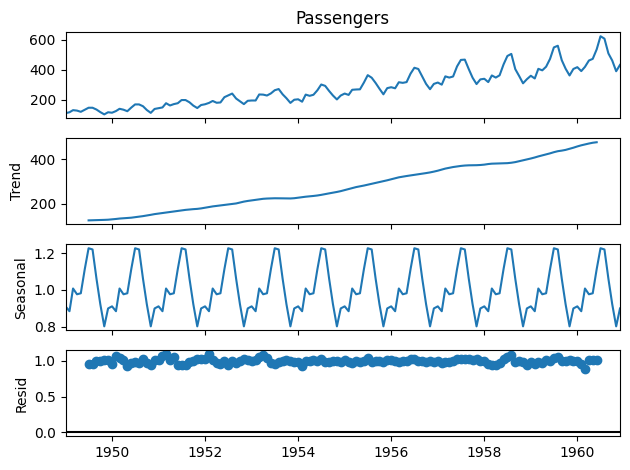

In [11]:
# Your Code Here
decomp_mult = seasonal_decompose(airline['Passengers'], model='multiplicative')
decomp_mult.plot()
plt.show()

# add manual attribute for check below
decomp_mult.model = 'multiplicative'

In [12]:
#| Check your work
try:
    assert 'decomp_mult' in locals(), "Variable 'decomp_mult' missing."
    assert decomp_mult.model == 'multiplicative', "Model should be multiplicative."
    print("Exercise 1.1 Passed!")
except Exception as e:
    print(f"Exercise 1.1 Failed: {e}")

Exercise 1.1 Passed!


### Exercise 1.2: MSTL Decomposition
**Instruction**: The `airline` data has a clear monthly seasonality (period=12). Use `MSTL` from `statsmodels` to decompose the data. Store the result in `mstl_fit`.

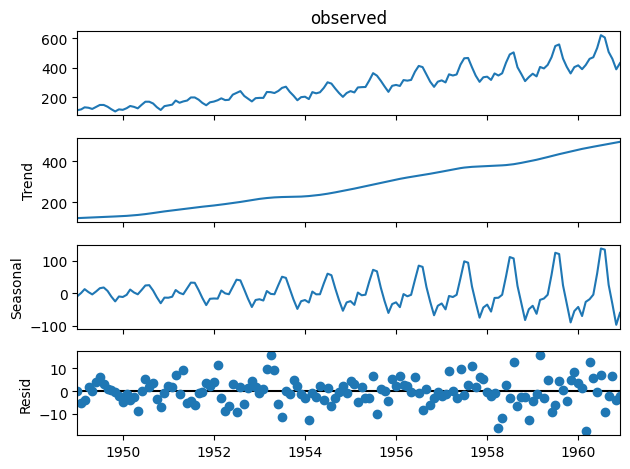

In [13]:
# Your Code Here
mstl_fit = MSTL(airline['Passengers'], periods=(12,)).fit()
mstl_fit.plot()
plt.show()

In [14]:
#| Check your work
try:
    assert 'mstl_fit' in locals(), "Variable 'mstl_fit' missing."
    assert hasattr(mstl_fit, 'seasonal'), "Result should have seasonal component."
    print("Exercise 1.2 Passed!")
except Exception as e:
    print(f"Exercise 1.2 Failed: {e}")

Exercise 1.2 Passed!


### Exercise 1.3: Feature Extraction (Strength of Trend)
**Instruction**: Calculate the "Strength of Trend" feature for the `airline` data using the `mstl_fit` result.
The formula is $F_T = \max\left(0, 1 - \frac{\text{Var}(R_t)}{\text{Var}(T_t + R_t)}\right)$, where $R_t$ is the remainder and $T_t$ is the trend.
Assign the result to `trend_strength`.

In [15]:
# Your Code Here
trend = mstl_fit.trend
resid = mstl_fit.resid
trend_strength = max(0, 1 - resid.var() / (trend + resid).var())

In [16]:
#| Check your work
try:
    assert 'trend_strength' in locals(), "Variable 'trend_strength' missing."
    assert 0 <= trend_strength <= 1, "Strength should be between 0 and 1."
    print(f"Exercise 1.3 Passed! Trend Strength: {trend_strength:.4f}")
except Exception as e:
    print(f"Exercise 1.3 Failed: {e}")

Exercise 1.3 Passed! Trend Strength: 0.9973


## Part 2: Textbook Exercises

Complete the following exercises from *Forecasting: Principles and Practice, the Pythonic Way*.

### Chapter 3: Time Series Decomposition

#### Question 3.1
> Consider the GDP information in `global_economy`. Plot the GDP per capita for each country over time. Which country has the highest GDP per capita? How has this changed over time?

#### Question 3.2
> For each of the following series, make a graph of the data. If transforming seems appropriate, do so and describe the effect: United States GDP from `global_economy`, Slaughter of Victorian "Bulls, bullocks and steers" from `aus_livestock`, Victorian Electricity Demand from `vic_elec`, and Gas production from `aus_production`.

#### Question 3.3
> Why is a Box-Cox transformation unhelpful for the `canadian_gas` data?

#### Question 3.4
> What Box-Cox transformation would you select for your retail data (from Exercise 7 in Section 2.10)?

#### Question 3.5
> For the following series, find an appropriate Box-Cox transformation to stabilise the variance: `Tobacco` from `aus_production`, `Economy` class passengers between Melbourne and Sydney from `ansett`, and `Pedestrian` counts at Southern Cross Station from `pedestrian`.

#### Question 3.6
> Consider the last five years of the Gas data from `aus_production`. Plot the time series. Use `seasonal_decompose` (multiplicative) to calculate trend-cycle and seasonal indices. Compute and plot seasonally adjusted data. Add an outlier and recompute.

#### Question 3.7
> Decompose your retail time series using the MSTL method. Does it reveal any outliers or unusual features?

#### Question 3.8
> Write about 3-5 sentences describing the results of the decomposition for the persons in the civilian labour force in Australia (Figures 3.13 and 3.14). Is the recession of 1991/1992 visible?

### Chapter 4: Time Series Features

#### Question 4.1
> Write a function to compute the mean and standard deviation of a time series and apply it to the `PBS` data. Plot the series with the highest mean and the series with the lowest standard deviation.

#### Question 4.2
> Use `sns.pairplot()` to look at the relationships between the STL-based features for the holiday series in the `tourism` data. Which is the peak quarter for holidays in each state?

#### Question 4.3
> Use a feature-based approach to look for outlying series in the `PBS` data. What is unusual about the series you identify?

In [27]:
# Question 3.1
gdp_pc = (
    pd.read_csv('sample_data/global_economy.csv')
          .assign(GDP_per_capita=lambda d: d['GDP']/d['Population'])
          .dropna(subset=['GDP_per_capita'])
          )

# Highest in the most recent year
latest = gdp_pc[gdp_pc['ds'] == gdp_pc['ds'].max()]
print(latest.nlargest(5, 'GDP_per_capita')[['unique_id', 'ds', 'GDP_per_capita']])

# Highest in any year
print(gdp_pc.nlargest(5, 'GDP_per_capita')[['unique_id', 'ds', 'GDP_per_capita']])




              unique_id    ds  GDP_per_capita
8403         Luxembourg  2017   104103.036747
8461   Macao SAR, China  2017    80892.821329
13439       Switzerland  2017    80189.696861
10491            Norway  2017    75504.566255
6083            Iceland  2017    70056.873392
          unique_id    ds  GDP_per_capita
9502         Monaco  2014   185152.527227
9496         Monaco  2008   180640.125115
8110  Liechtenstein  2014   179308.075616
8109  Liechtenstein  2013   173528.150454
9501         Monaco  2013   172588.877783


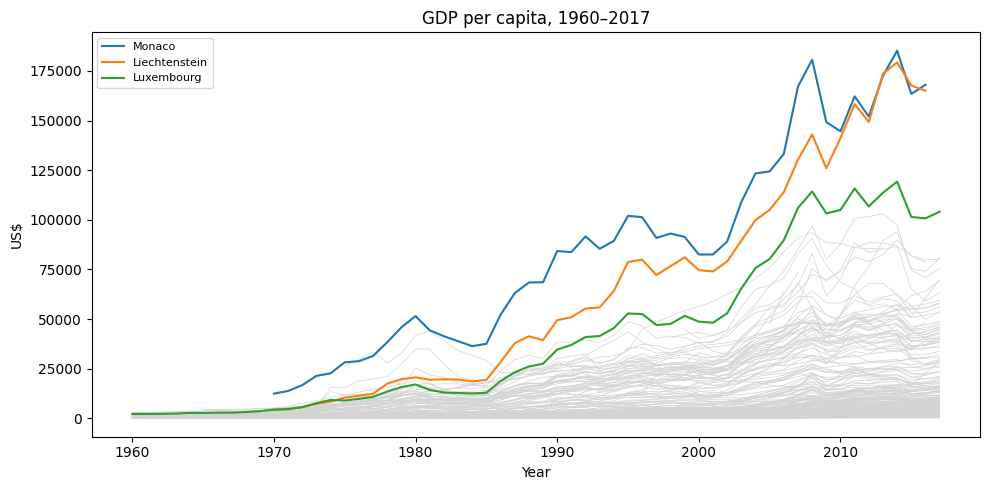

In [28]:
top = gdp_pc.nlargest(30, 'GDP_per_capita')['unique_id'].unique()[:5]

fig, ax = plt.subplots(figsize=(10, 5))

for country, grp in gdp_pc.groupby('unique_id'):
    ax.plot(grp['ds'], grp['GDP_per_capita'],
            color='lightgrey', linewidth=0.5, zorder=1)

for country in top:
    grp = gdp_pc[gdp_pc['unique_id'] == country]
    ax.plot(grp['ds'], grp['GDP_per_capita'], linewidth=1.5,
            label=country, zorder=2)

ax.legend(fontsize=8)
ax.set(title='GDP per capita, 1960–2017', xlabel='Year', ylabel='US$')
plt.tight_layout()
plt.show()

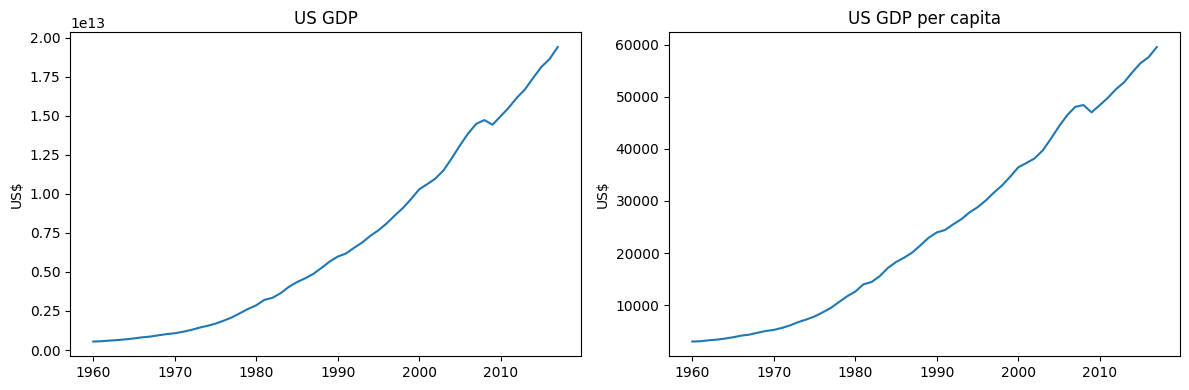

In [30]:
# Question 3.2
us_gdp = gdp_pc[gdp_pc['unique_id'] == 'United States']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(us_gdp['ds'], us_gdp['GDP'])
axes[0].set(title='US GDP', ylabel='US$')

axes[1].plot(us_gdp['ds'], us_gdp['GDP'] / us_gdp['Population'])
axes[1].set(title='US GDP per capita', ylabel='US$')
plt.tight_layout()

<Axes: title={'center': 'Slaughter — bulls, bullocks and steers, Victoria'}, xlabel='ds'>

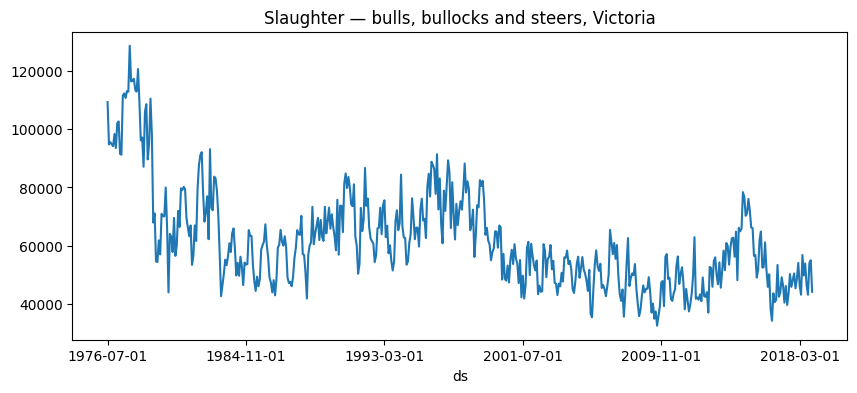

In [36]:
bull_livestock = (
        pd.read_csv('sample_data/aus_livestock.csv')
          .loc[lambda x: x['unique_id'] == 'Victoria_Bulls, bullocks and steers']
          )
bull_livestock.set_index('ds')['y'].plot(figsize=(10, 4),
    title='Slaughter — bulls, bullocks and steers, Victoria')

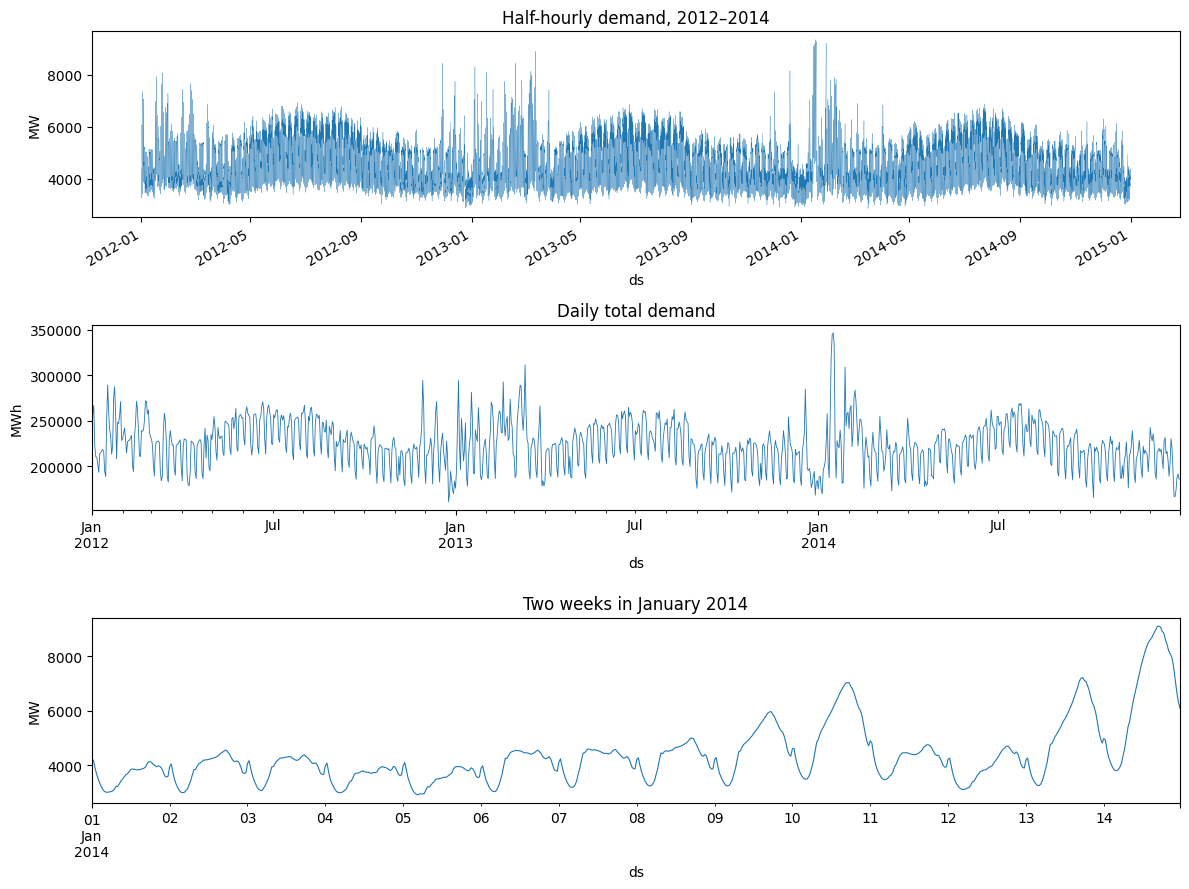

In [47]:
vic_elec_demand = (
        pd.read_csv('sample_data/vic_elec.csv', parse_dates=['ds'])
          .loc[lambda x: x['unique_id'] == 'Demand']
          .set_index('ds')['y']

        )


fig, axes = plt.subplots(3, 1, figsize=(12, 9))

# Half-hourly — too dense to read, which is the point
vic_elec_demand.plot(ax=axes[0], linewidth=0.2)
axes[0].set(title='Half-hourly demand, 2012–2014', ylabel='MW')

# Daily total
vic_elec_demand.resample('D').sum().plot(ax=axes[1], linewidth=0.6)
axes[1].set(title='Daily total demand', ylabel='MWh')

# One summer fortnight — reveals the daily cycle
vic_elec_demand['2014-01-01':'2014-01-14'].plot(ax=axes[2], linewidth=0.8)
axes[2].set(title='Two weeks in January 2014', ylabel='MW')

plt.tight_layout()
plt.show()

lambda = 0.950


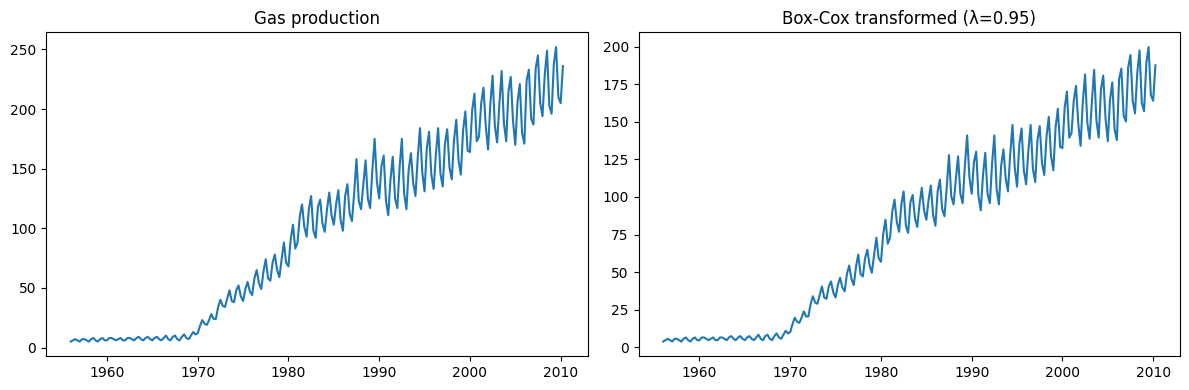

In [51]:
from scipy.stats import boxcox, boxcox_normmax
gas_prod = (
        pd.read_csv('sample_data/aus_production.csv', parse_dates=['ds'])
        )
lam = boxcox_normmax(gas_prod['Gas'])
print(f"lambda = {lam:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(gas_prod['ds'], gas_prod['Gas'])
axes[0].set(title='Gas production')
axes[1].plot(gas_prod['ds'], boxcox(gas_prod['Gas'], lam))
axes[1].set(title=f'Box-Cox transformed (λ={lam:.2f})')
plt.tight_layout()

lambda = 0.606


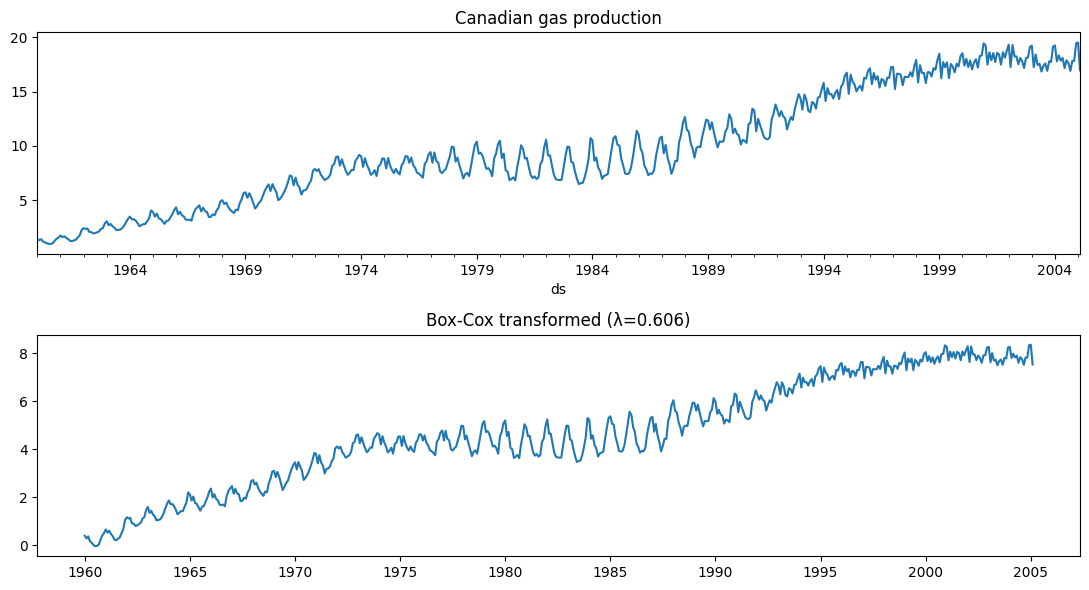

In [57]:
# Question 3.3
from scipy.stats import boxcox, boxcox_normmax
canada_gas = (
        pd.read_csv('sample_data/canadian_gas.csv', parse_dates=['ds'])
        .set_index('ds')['y']
        )

lam = boxcox_normmax(canada_gas)
print(f"lambda = {lam:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
canada_gas.plot(ax=axes[0], title='Canadian gas production')
axes[1].plot(canada_gas.index, boxcox(canada_gas.values, lam))
axes[1].set(title=f'Box-Cox transformed (λ={lam:.3f})')
plt.tight_layout()

# A Box-Cox transformation is unhelpful here because the seasonal variation is not a monotonic function of the series level.

lambda = 0.2115


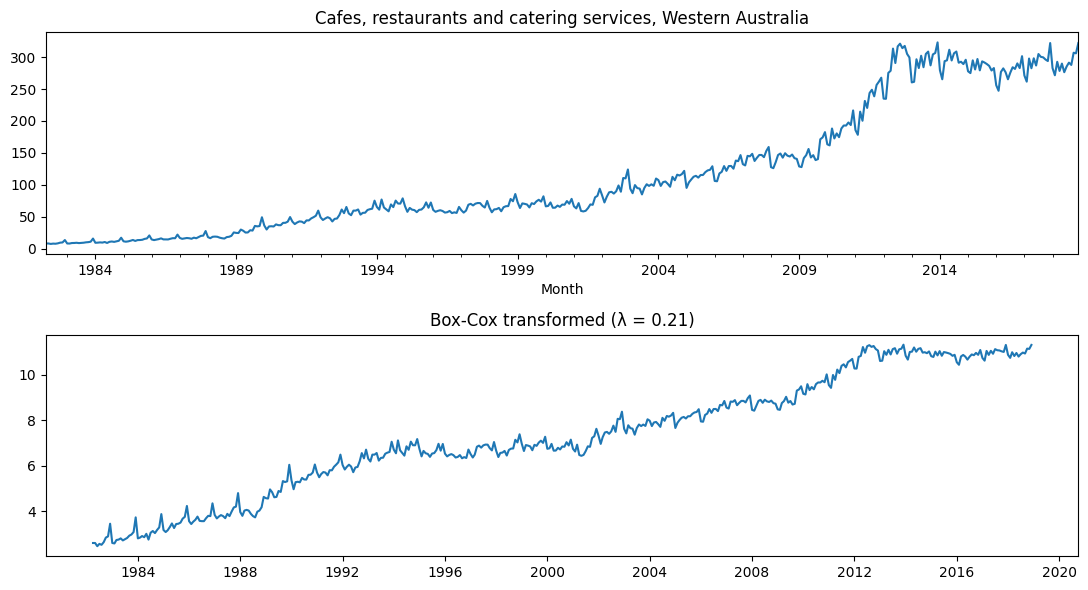

In [60]:
# Question 3.4

aus_retail = (
        pd.read_csv('sample_data/aus_retail.csv', parse_dates=['Month'])
        )

random = np.random.RandomState(12345678)
random_series_id = random.choice(aus_retail["Series ID"].unique())
myseries = aus_retail.loc[aus_retail["Series ID"] == random_series_id]

y = myseries.set_index('Month')['Turnover']

lam = boxcox_normmax(y.values)
print(f"lambda = {lam:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
y.plot(ax=axes[0], title=f'{myseries["Industry"].iloc[0]}, {myseries["State"].iloc[0]}')
axes[1].plot(y.index, boxcox(y.values, lam))
axes[1].set(title=f'Box-Cox transformed (λ = {lam:.2f})')
plt.tight_layout()
plt.show()

# Maximum-likelihood estimation gives λ ≈ 0.21. Since this is close to zero, a log transformation (λ = 0) is preferable here.

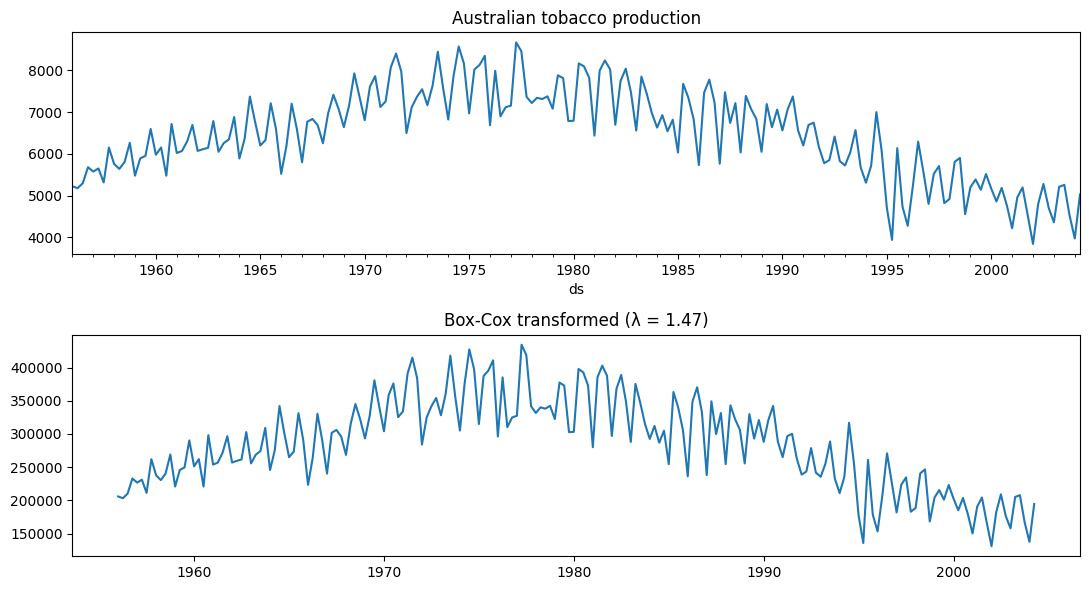

In [65]:
# Question 3.5
# For the following series, find an appropriate Box-Cox transformation to
# stabilise the variance: Tobacco from aus_production, Economy class passengers
# between Melbourne and Sydney from ansett, and Pedestrian counts at Southern Cross Station from pedestrian.

from scipy.stats import boxcox, boxcox_normmax

def find_lambda(y, title):
    lam = boxcox_normmax(y.values)
    fig, axes = plt.subplots(2, 1, figsize=(11, 6))
    y.plot(ax=axes[0], title=title)
    axes[1].plot(y.index, boxcox(y.values, lam))
    axes[1].set(title=f'Box-Cox transformed (λ = {lam:.2f})')
    plt.tight_layout()
    plt.show()
    return lam

aus_tobacco = (
        pd.read_csv('sample_data/aus_production.csv', parse_dates=['ds'])
        ).set_index('ds')['Tobacco'].dropna()
lam_tobacco = find_lambda(aus_tobacco, 'Australian tobacco production')

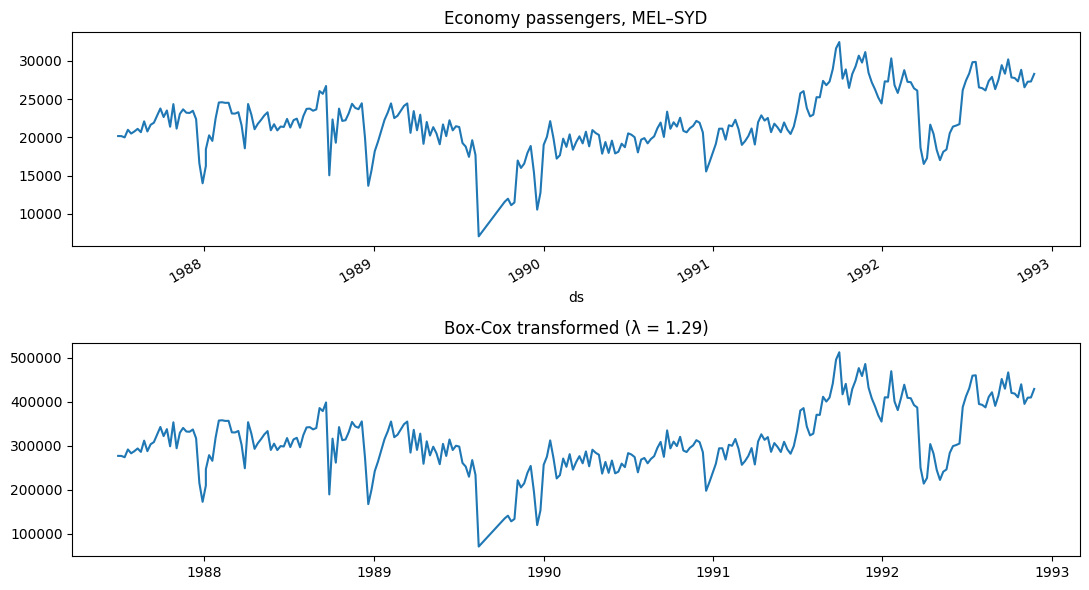

np.float64(1.2900813038568535)

In [66]:
ansett = pd.read_csv('sample_data/ansett.csv', parse_dates=['ds'])
mel_syd = (
    ansett.loc[(ansett['Airports'] == 'MEL-SYD') & (ansett['Class'] == 'Economy')]
          .set_index('ds')['y']
)
mel_syd_nz = mel_syd[mel_syd > 0]
find_lambda(mel_syd_nz, 'Economy passengers, MEL–SYD')    # λ ≈ 1.29

In [ ]:
pedestrian = pd.read_csv('sample_data/pedestrian.csv', parse_dates=['Date_Time'])
sx = (
    pedestrian.loc[pedestrian['unique_id'] == 'Southern Cross Station']
              .set_index('Date_Time')['y']
)
sx_nz = sx[sx > 0]
find_lambda(sx_nz, 'Pedestrian counts, Southern Cross')   # λ ≈ 0.10

# Tobacco: λ ≈ 1.47 — no transformation. λ above 1 means variance isn't growing with the level.
# λ = 1 is already "no transformation," and 1.47 isn't far enough off to justify one.

# Ansett MEL–SYD: λ ≈ 1.29 — no transformation. Seven zeros between 21 Aug and 2 Oct 1989 (the pilots' strike)
# must be removed first, since Box-Cox needs strictly positive values. Yeo-Johnson gives λ ≈ 1.27 and the same conclusion.

# Southern Cross: λ ≈ 0.10 — use log (λ = 0). The only one that genuinely needs transforming.
# Hourly counts range from 0 to several thousand with variance clearly scaling with the level,
# and log is easier to interpret since differences become percentage changes.

## Grading Rubric
- **Correctness (40%)**: Does the code run and produce the expected output?
- **Code Quality (30%)**: Is the code clean, commented, and efficient?
- **Analysis (30%)**: Are the interpretations and explanations clear and accurate?